In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_style("whitegrid")

print("All libraries loaded.")

All libraries loaded.


In [2]:
from src.data.loader import BookCrossingLoader
from src.data.preprocessor import BookCrossingPreprocessor

loader = BookCrossingLoader("../data/raw")
raw = loader.load_all(verbose=False)

prep = BookCrossingPreprocessor()
clean = prep.fit_transform(raw)

users   = clean.users
books   = clean.books
ratings = clean.ratings

print(f"Users with age:    {clean.n_users_with_age:,}")
print(f"Users without age: {clean.n_users_without_age:,}")

Users with age:    165,917
Users without age: 112,942


In [3]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

# Full sparse matrix
sparse_matrix = prep.build_sparse_matrix(clean)
print(f"Sparse matrix shape: {sparse_matrix.shape}")

# Reduce to 50 latent components (same as original Task 3 submission)
svd = TruncatedSVD(n_components=50, random_state=42)
X_all = svd.fit_transform(sparse_matrix)

print(f"Reduced matrix shape: {X_all.shape}")
print(f"Explained variance:   {svd.explained_variance_ratio_.sum():.4%}")

Sparse matrix shape: (105283, 340054)
Reduced matrix shape: (105283, 50)
Explained variance:   11.8487%


In [4]:
# Map user_id to row index in sparse matrix
user_to_idx = clean.user_to_idx

# Known ages — training set
known_users = clean.users_with_age.copy()
known_users['row_idx'] = known_users['user_id'].map(user_to_idx)
known_users = known_users.dropna(subset=['row_idx'])
known_users['row_idx'] = known_users['row_idx'].astype(int)

X_known = X_all[known_users['row_idx'].values]
y_known = known_users['age'].values.astype(float)

# Missing ages — prediction set
missing_users = clean.users_without_age.copy()
missing_users['row_idx'] = missing_users['user_id'].map(user_to_idx)
missing_users = missing_users.dropna(subset=['row_idx'])
missing_users['row_idx'] = missing_users['row_idx'].astype(int)

X_missing = X_all[missing_users['row_idx'].values]
missing_user_ids = missing_users['user_id'].values

print(f"Training set (known age):    {X_known.shape}")
print(f"Prediction set (missing age): {X_missing.shape}")
print(f"Age range in training set:   {int(y_known.min())} – {int(y_known.max())}")
print(f"Mean age:                    {y_known.mean():.1f}")

Training set (known age):    (61354, 50)
Prediction set (missing age): (43929, 50)
Age range in training set:   5 – 100
Mean age:                    35.4


In [5]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ── Model 1: Linear Regression ───────────────────────────────────────
print("Training Linear Regression...")
lin_reg = LinearRegression()
lin_pred = cross_val_predict(lin_reg, X_known, y_known, cv=kfold)
lin_rmse = rmse(y_known, lin_pred)
print(f"  Linear Regression RMSE: {lin_rmse:.4f}")

# ── Model 2: Logistic Regression (binned) ────────────────────────────
print("Training Logistic Regression (binned)...")
age_bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 120]
bin_labels = np.arange(len(age_bins) - 1)
bin_midpoints = np.array([(age_bins[i] + age_bins[i+1]) / 2
                           for i in range(len(age_bins) - 1)])

y_bins = pd.cut(y_known, bins=age_bins, labels=bin_labels,
                include_lowest=True).astype(int)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_rmse_scores = []

for train_idx, test_idx in kfold.split(X_known):
    X_train, X_test     = X_known[train_idx], X_known[test_idx]
    y_train_bins        = y_bins[train_idx]
    y_test_ages         = y_known[test_idx]
    log_reg.fit(X_train, y_train_bins)
    pred_bins  = log_reg.predict(X_test)
    pred_ages  = bin_midpoints[pred_bins]
    log_rmse_scores.append(rmse(y_test_ages, pred_ages))

log_rmse = np.mean(log_rmse_scores)
print(f"  Logistic Regression RMSE: {log_rmse:.4f}")

# ── Model 3: Decision Tree Regressor ─────────────────────────────────
print("Training Decision Tree Regressor...")
tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
tree_pred = cross_val_predict(tree_reg, X_known, y_known, cv=kfold)
tree_rmse = rmse(y_known, tree_pred)
print(f"  Decision Tree RMSE: {tree_rmse:.4f}")

print("\nAll models trained.")

Training Linear Regression...
  Linear Regression RMSE: 19.2207
Training Logistic Regression (binned)...
  Logistic Regression RMSE: 16.8767
Training Decision Tree Regressor...
  Decision Tree RMSE: 14.3196

All models trained.


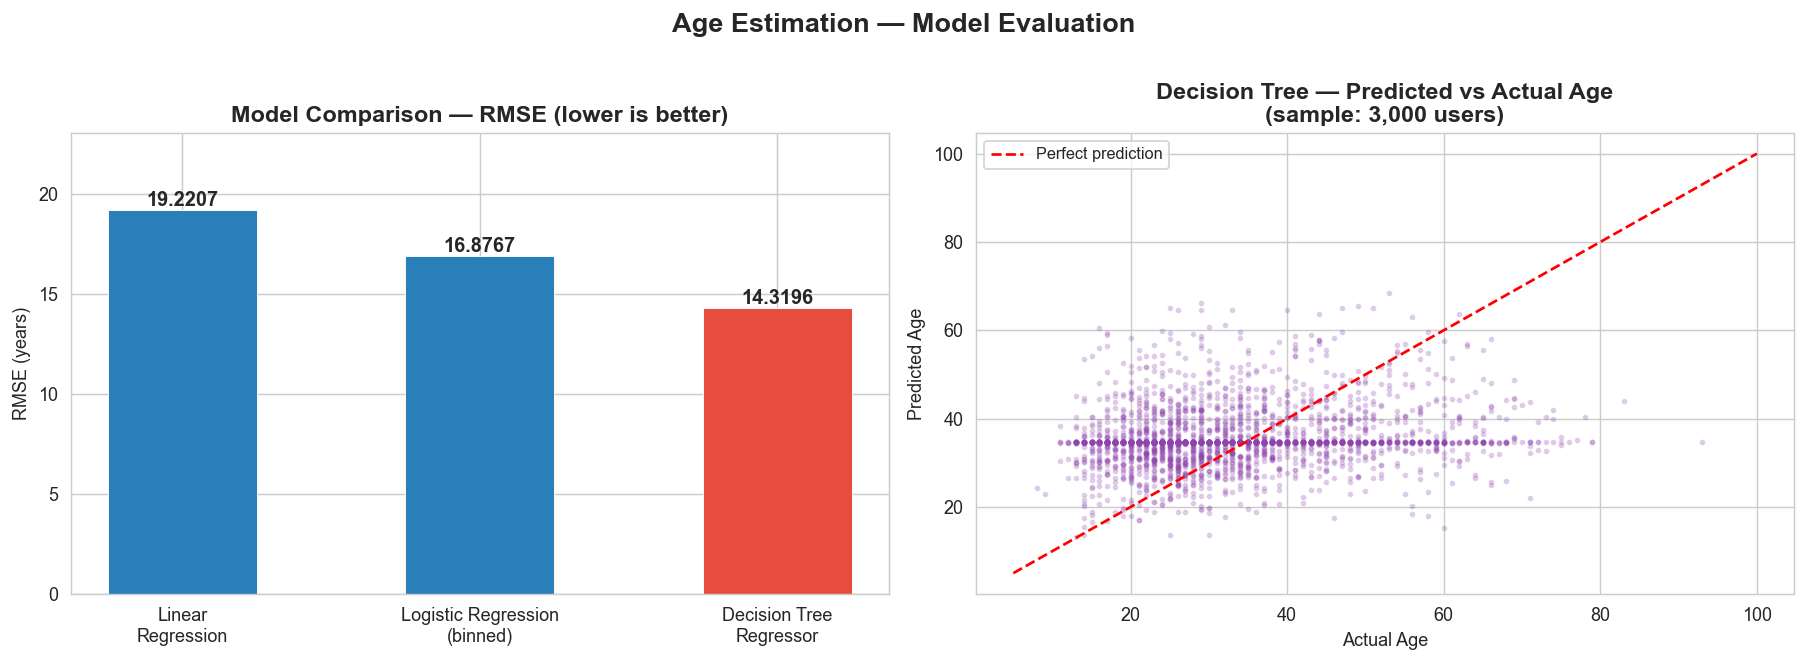

Linear Regression RMSE:      19.2207
Logistic Regression RMSE:    16.8767
Decision Tree RMSE:          14.3196  ← Best


In [6]:
model_names = ['Linear\nRegression', 'Logistic Regression\n(binned)', 'Decision Tree\nRegressor']
rmse_values = [lin_rmse, log_rmse, tree_rmse]
colors      = ['#e74c3c' if r == min(rmse_values) else '#2980b9' for r in rmse_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart
bars = axes[0].bar(model_names, rmse_values, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_title('Model Comparison — RMSE (lower is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE (years)')
axes[0].set_ylim(0, max(rmse_values) * 1.2)
for bar, val in zip(bars, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
best_model = model_names[rmse_values.index(min(rmse_values))]
axes[0].annotate(f'Best model', xy=(rmse_values.index(min(rmse_values)), min(rmse_values)),
                 xytext=(rmse_values.index(min(rmse_values)), min(rmse_values) * 0.5),
                 fontsize=9, color='#e74c3c', ha='center',
                 arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Right: predicted vs actual (Decision Tree — best model)
axes[1].scatter(y_known[:3000], tree_pred[:3000], alpha=0.2, s=5, color='#8e44ad')
axes[1].plot([y_known.min(), y_known.max()],
             [y_known.min(), y_known.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('Decision Tree — Predicted vs Actual Age\n(sample: 3,000 users)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Age')
axes[1].set_ylabel('Predicted Age')
axes[1].legend(fontsize=9)

plt.suptitle('Age Estimation — Model Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/age_model_comparison.png', bbox_inches='tight')
plt.show()

print(f"Linear Regression RMSE:      {lin_rmse:.4f}")
print(f"Logistic Regression RMSE:    {log_rmse:.4f}")
print(f"Decision Tree RMSE:          {tree_rmse:.4f}  ← Best")

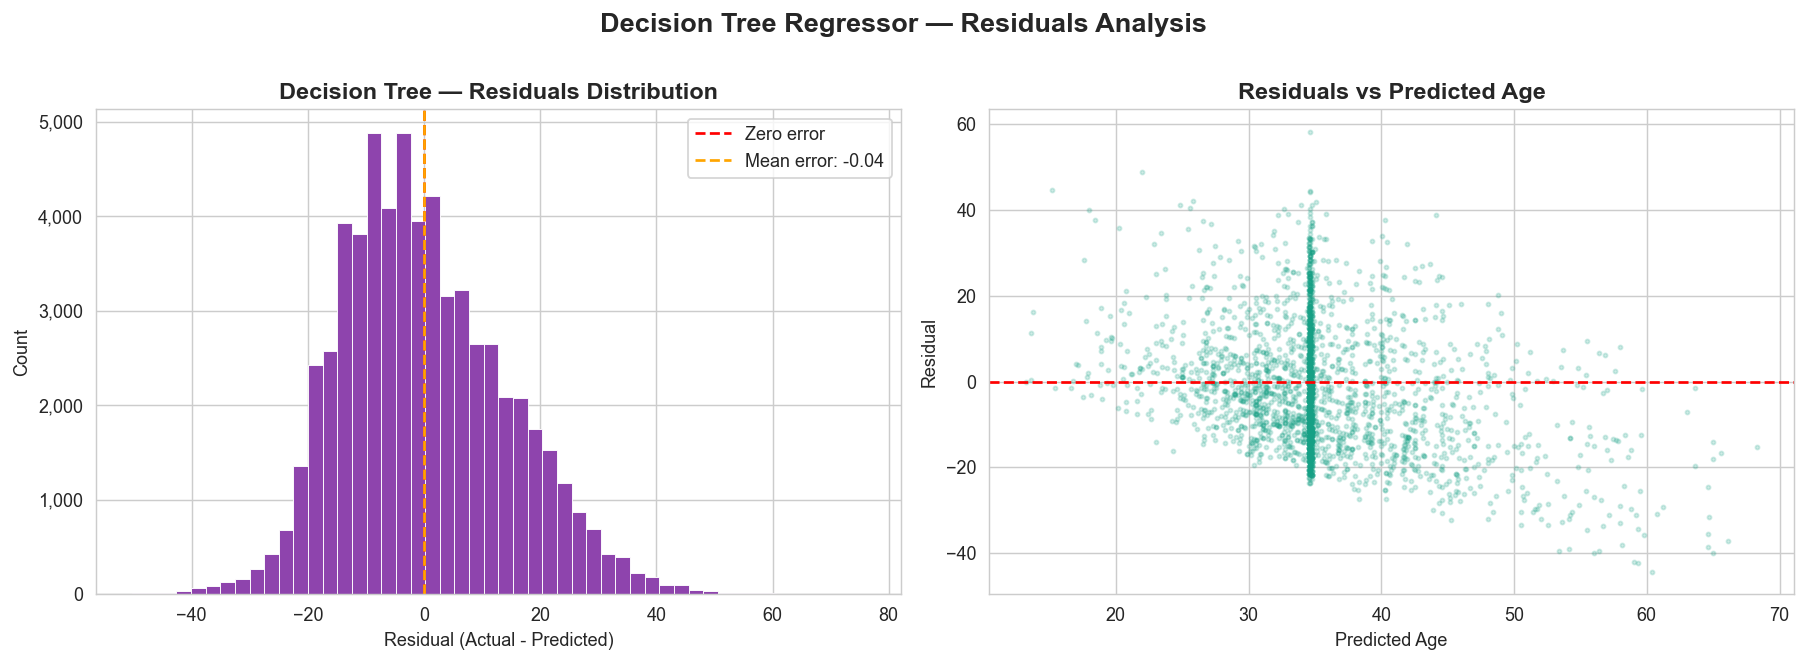

Mean residual:   -0.0392
Std of residuals: 14.3195
% within 5 years: 26.39%
% within 10 years: 50.42%


In [7]:
residuals = y_known - tree_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residuals histogram
axes[0].hist(residuals, bins=50, color='#8e44ad', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean error: {residuals.mean():.2f}')
axes[0].set_title('Decision Tree — Residuals Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()

# Right: residuals vs predicted
axes[1].scatter(tree_pred[:3000], residuals[:3000], alpha=0.2, s=5, color='#16a085')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted Age', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Age')
axes[1].set_ylabel('Residual')

plt.suptitle('Decision Tree Regressor — Residuals Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/age_residuals.png', bbox_inches='tight')
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.4f}")
print(f"% within 5 years: {(np.abs(residuals) <= 5).mean():.2%}")
print(f"% within 10 years: {(np.abs(residuals) <= 10).mean():.2%}")

In [8]:
print("Training final Decision Tree on full training set...")
best_model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
best_model.fit(X_known, y_known)

# Predict missing ages
predicted_ages = best_model.predict(X_missing)
predicted_ages = np.clip(predicted_ages, 5, 100)
predicted_ages = np.round(predicted_ages).astype(int)

print(f"Predicted ages for {len(predicted_ages):,} users")
print(f"Predicted age range: {predicted_ages.min()} – {predicted_ages.max()}")
print(f"Mean predicted age:  {predicted_ages.mean():.1f}")
print(f"Sample predictions:  {list(zip(missing_user_ids[:5], predicted_ages[:5]))}")

Training final Decision Tree on full training set...
Predicted ages for 43,929 users
Predicted age range: 13 – 69
Mean predicted age:  35.9
Sample predictions:  [('7', np.int64(35)), ('8', np.int64(37)), ('9', np.int64(53)), ('12', np.int64(35)), ('14', np.int64(37))]


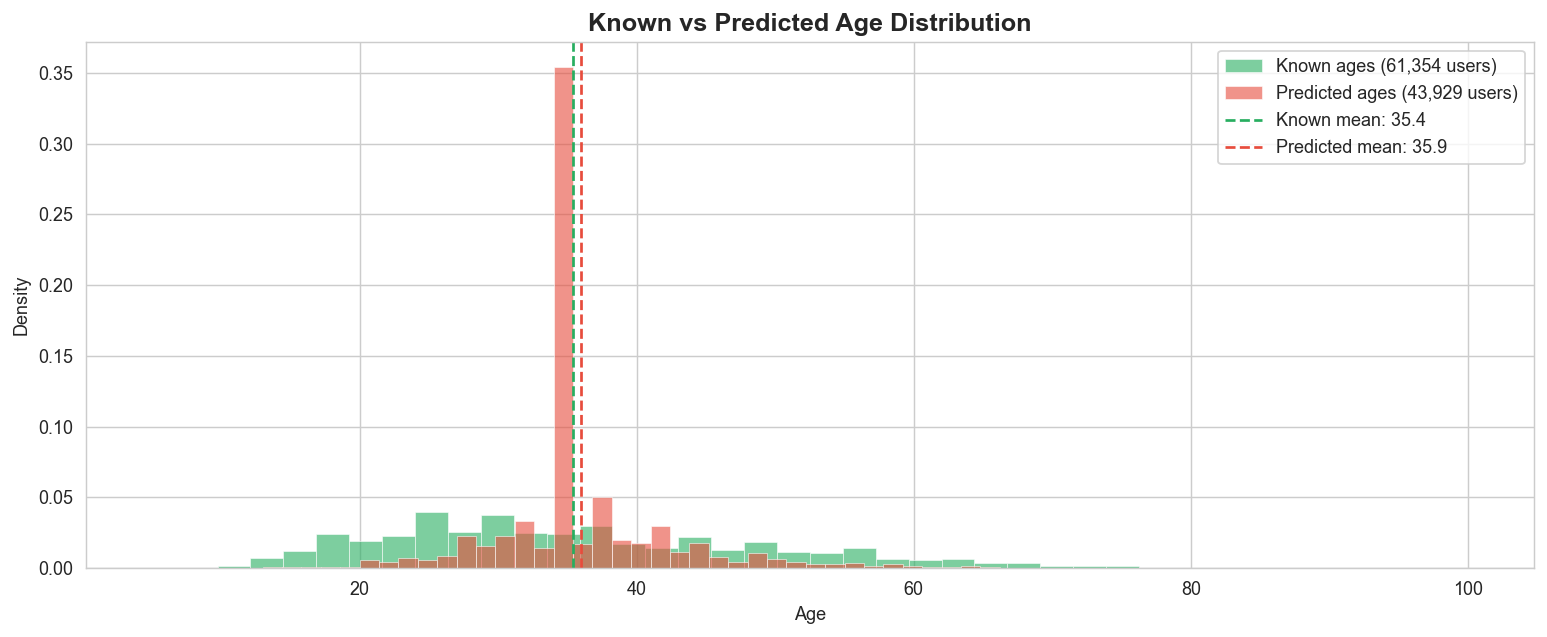

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(y_known, bins=40, alpha=0.6, color='#27ae60',
        edgecolor='white', linewidth=0.5, label=f'Known ages ({len(y_known):,} users)', density=True)
ax.hist(predicted_ages, bins=40, alpha=0.6, color='#e74c3c',
        edgecolor='white', linewidth=0.5, label=f'Predicted ages ({len(predicted_ages):,} users)', density=True)

ax.axvline(y_known.mean(), color='#27ae60', linestyle='--',
           linewidth=1.5, label=f'Known mean: {y_known.mean():.1f}')
ax.axvline(predicted_ages.mean(), color='#e74c3c', linestyle='--',
           linewidth=1.5, label=f'Predicted mean: {predicted_ages.mean():.1f}')

ax.set_title('Known vs Predicted Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../assets/age_distribution_comparison.png', bbox_inches='tight')
plt.show()

In [10]:
# Build book title list per user
isbn_to_title = books.set_index('isbn')['title'].to_dict()

user_books = (
    ratings[ratings['rating'] > 0]
    .merge(books[['isbn', 'title']], on='isbn', how='left')
    .dropna(subset=['title'])
    .groupby('user_id')['title']
    .apply(lambda titles: ','.join(sorted(set(titles))))
    .reset_index()
    .rename(columns={'title': 'List of Book Titles read by the user separated by commas'})
)

# Build predictions DataFrame
pred_df = pd.DataFrame({
    'User ID':       missing_user_ids,
    'Estimated Age': predicted_ages
})

pred_df = pred_df.merge(user_books, left_on='User ID', right_on='user_id', how='left')
pred_df = pred_df.drop(columns=['user_id'])

pred_df.to_csv('../outputs/Task3_Estimated_User_Ages.csv', sep=';', index=False)

print(f"Output saved: outputs/Task3_Estimated_User_Ages.csv")
print(f"Rows: {len(pred_df):,}")
print()
print(pred_df.head(5)[['User ID', 'Estimated Age']].to_string(index=False))

Output saved: outputs/Task3_Estimated_User_Ages.csv
Rows: 43,929

User ID  Estimated Age
      7             35
      8             37
      9             53
     12             35
     14             37


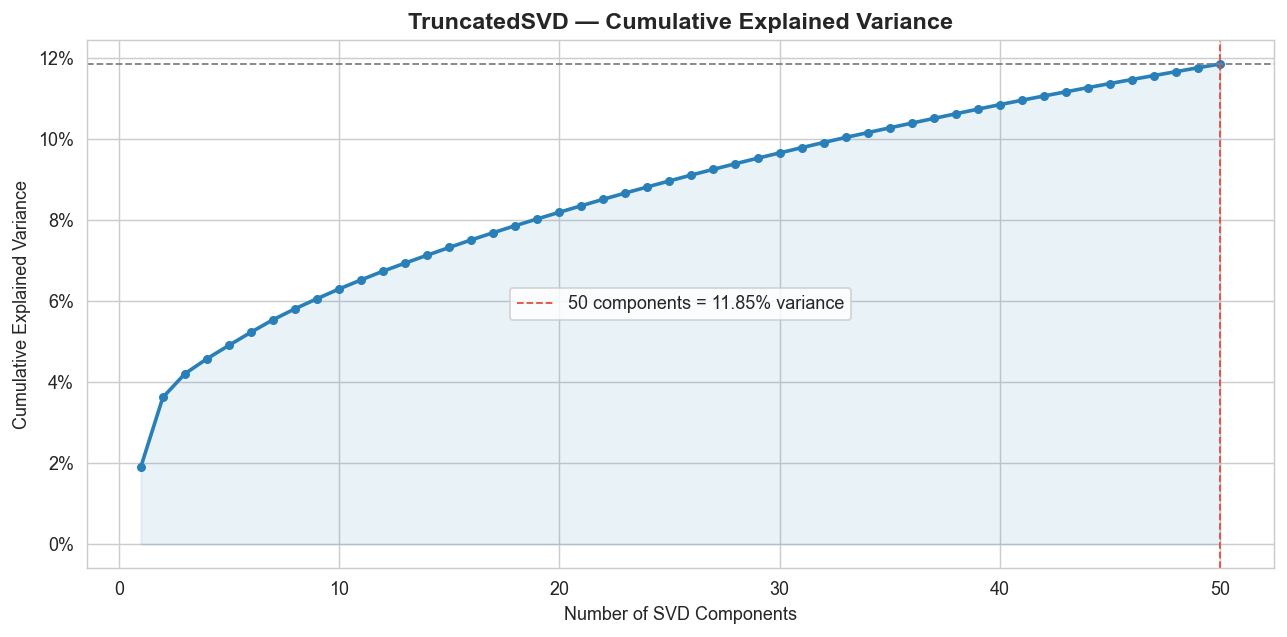

Variance explained by 50 components: 11.8487%


In [11]:
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 51), cumulative_variance, 'o-', color='#2980b9',
        linewidth=2, markersize=4)
ax.axhline(cumulative_variance[-1], color='gray', linestyle='--', linewidth=1)
ax.axvline(50, color='#e74c3c', linestyle='--', linewidth=1,
           label=f'50 components = {cumulative_variance[-1]:.2%} variance')
ax.fill_between(range(1, 51), cumulative_variance, alpha=0.1, color='#2980b9')
ax.set_title('TruncatedSVD — Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of SVD Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../assets/svd_explained_variance.png', bbox_inches='tight')
plt.show()

print(f"Variance explained by 50 components: {cumulative_variance[-1]:.4%}")

In [12]:
print("=" * 55)
print("  Module 4 Complete — Age Estimation")
print("=" * 55)
print()
print("  Models trained:")
print(f"    Linear Regression RMSE:   {lin_rmse:.4f}")
print(f"    Logistic Regression RMSE: {log_rmse:.4f}")
print(f"    Decision Tree RMSE:       {tree_rmse:.4f}  ← Best")
print()
print(f"  Predicted ages for {len(predicted_ages):,} users")
print()
print("  Output files:")
print("    outputs/Task3_Estimated_User_Ages.csv")
print()
print("  Charts saved:")
import os
charts = ['age_model_comparison.png', 'age_residuals.png',
          'age_distribution_comparison.png', 'svd_explained_variance.png']
for c in charts:
    path = f'../assets/{c}'
    if os.path.exists(path):
        print(f"    assets/{c}  ({os.path.getsize(path)/1024:.1f} KB)")

  Module 4 Complete — Age Estimation

  Models trained:
    Linear Regression RMSE:   19.2207
    Logistic Regression RMSE: 16.8767
    Decision Tree RMSE:       14.3196  ← Best

  Predicted ages for 43,929 users

  Output files:
    outputs/Task3_Estimated_User_Ages.csv

  Charts saved:
    assets/age_model_comparison.png  (121.6 KB)
    assets/age_residuals.png  (124.9 KB)
    assets/age_distribution_comparison.png  (44.4 KB)
    assets/svd_explained_variance.png  (53.6 KB)
